# **MNIST Fashion Klassifikation mit CNN**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Gerätekonfiguration
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("CPU")
print(f"Verwende: {device}")

# Datentransformationen
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalisierung auf [-1, 1]
])

# Datensatz laden
train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Klassennamen
classes = ['T-Shirt', 'Hose', 'Pullover', 'Kleid', 'Mantel',
           'Sandale', 'Hemd', 'Sneaker', 'Tasche', 'Stiefelette']

✓ Apple Silicon GPU (MPS)
Verwende: mps


## CNN Architektur

In [3]:
class FashionCNN(nn.Module):
    """
    CNN-Architektur für Fashion MNIST Klassifikation
    
    Architektur-Begründung:
    ----------------------
    1. CONV-Schichten: Extrahieren hierarchische Merkmale
       - Erste Schicht (32 Filter): Erkennt einfache Kanten/Texturen
       - Zweite Schicht (64 Filter): Kombiniert zu komplexeren Mustern
       - Dritte Schicht (128 Filter): Erkennt abstrakte Objektteile
    
    2. BatchNorm: Stabilisiert Training, ermöglicht höhere Lernraten
    
    3. MaxPooling (2x2): Reduziert Dimensionalität, erhöht Translations-
       invarianz (Position des Objekts weniger wichtig)
    
    4. Dropout: Regularisierung gegen Overfitting
       - 25% nach Conv-Blöcken (leicht, da Feature-Maps redundant)
       - 50% vor Ausgabe (stärker für FC-Layer)
    
    5. Fully Connected: Klassifikation basierend auf extrahierten Features
    """
    
    def __init__(self):
        super(FashionCNN, self).__init__()
        
        # Convolutional Block 1
        # Input: 1x28x28 → Output: 32x14x14
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # Erhält Größe
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 28→14
            nn.Dropout2d(0.25)
        )
        
        # Convolutional Block 2
        # Input: 32x14x14 → Output: 64x7x7
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14→7
            nn.Dropout2d(0.25)
        )
        
        # Convolutional Block 3
        # Input: 64x7x7 → Output: 128x3x3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 7→3
            nn.Dropout2d(0.25)
        )
        
        # Fully Connected Layers
        # 128 * 3 * 3 = 1152 Features
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)  # 10 Klassen
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# Modell erstellen
model = FashionCNN().to(device)
print(model)
print(f"\nAnzahl Parameter: {sum(p.numel() for p in model.parameters()):,}")

FashionCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace

## Training

In [4]:
def train_model(model, train_loader, test_loader, epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5
    )
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, correct, total = 0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100. * correct / total
        train_loss /= len(train_loader)
        
        # Validierung
        model.eval()
        val_loss, correct, total = 0, 0, 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        val_acc = 100. * correct / total
        val_loss /= len(test_loader)
        
        scheduler.step(val_loss)
        
        # Speichern
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    return history

# Training starten
history = train_model(model, train_loader, test_loader, epochs=15)

Epoch [1/15] Train Loss: 0.5560, Train Acc: 79.87% | Val Loss: 0.3392, Val Acc: 87.69%
Epoch [2/15] Train Loss: 0.3728, Train Acc: 86.39% | Val Loss: 0.3048, Val Acc: 88.74%
Epoch [3/15] Train Loss: 0.3276, Train Acc: 88.09% | Val Loss: 0.2764, Val Acc: 89.77%
Epoch [4/15] Train Loss: 0.3044, Train Acc: 88.89% | Val Loss: 0.2650, Val Acc: 90.21%
Epoch [5/15] Train Loss: 0.2872, Train Acc: 89.55% | Val Loss: 0.2483, Val Acc: 90.88%
Epoch [6/15] Train Loss: 0.2729, Train Acc: 90.06% | Val Loss: 0.2465, Val Acc: 91.08%
Epoch [7/15] Train Loss: 0.2594, Train Acc: 90.53% | Val Loss: 0.2405, Val Acc: 91.15%
Epoch [8/15] Train Loss: 0.2503, Train Acc: 90.96% | Val Loss: 0.2434, Val Acc: 91.11%
Epoch [9/15] Train Loss: 0.2462, Train Acc: 91.03% | Val Loss: 0.2280, Val Acc: 91.74%
Epoch [10/15] Train Loss: 0.2366, Train Acc: 91.40% | Val Loss: 0.2331, Val Acc: 91.60%
Epoch [11/15] Train Loss: 0.2286, Train Acc: 91.51% | Val Loss: 0.2338, Val Acc: 91.47%
Epoch [12/15] Train Loss: 0.2241, Train A

## Visualisierung und Auswertung

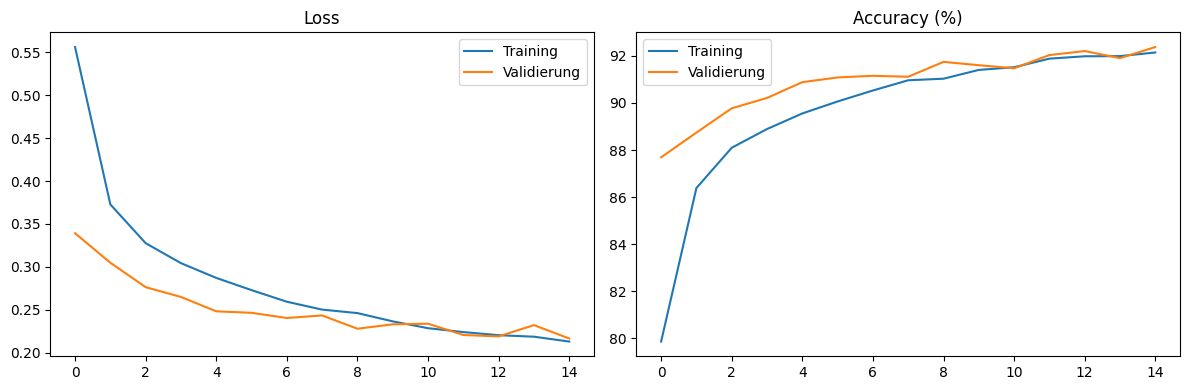

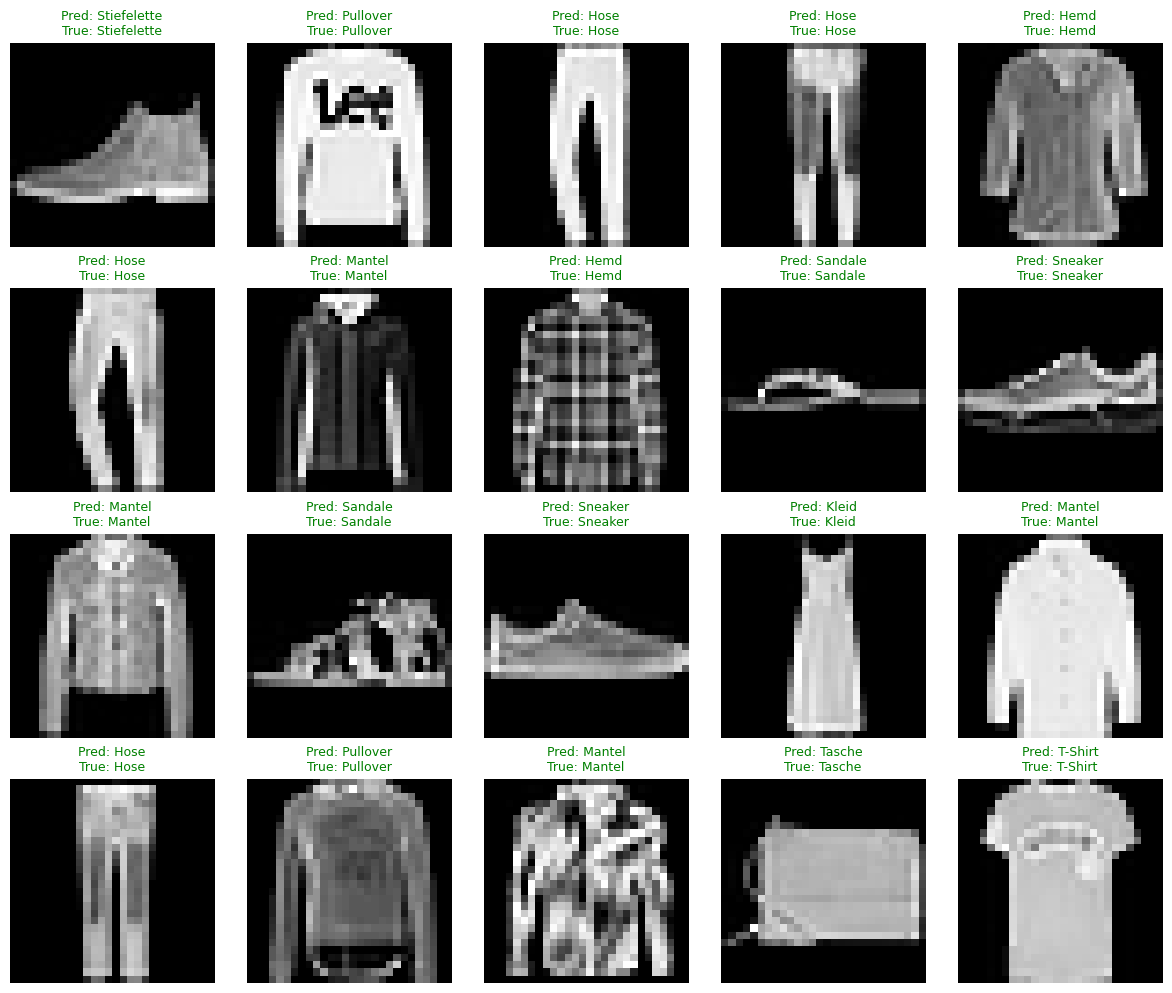

In [8]:
# Trainingsverlauf plotten
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Training')
axes[0].plot(history['val_loss'], label='Validierung')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Training')
axes[1].plot(history['val_acc'], label='Validierung')
axes[1].set_title('Accuracy (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

# Beispielvorhersagen
model.eval()
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
images, labels = next(iter(test_loader))

with torch.no_grad():
    predictions = model(images[:20].to(device)).argmax(1).cpu()

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    color = 'green' if predictions[i] == labels[i] else 'red'
    ax.set_title(f"Pred: {classes[predictions[i]]}\nTrue: {classes[labels[i]]}", 
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('predictions.png')
plt.show()